In [2]:
from utils.binaries import *
from utils.plotting import *
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

02:49:14 ( +103.3s) [INFO   ] -- import logging


02:49:14 (  +152ms) [INFO   ] -- import numpy as np
02:49:14 (    +5ms) [INFO   ] -- import uncertainties
02:49:14 (    +5ms) [INFO   ] -- import uncertainties
02:49:14 (  +660ms) [INFO   ] -- import pandas as pd
02:49:14 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
02:49:14 (    +1ms) [INFO   ] -- import binaries.tools as tools
02:49:14 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
02:49:14 (    +0ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
02:49:14 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
02:49:14 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
02:49:14 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
02:49:14 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
02:49:15 (  +331ms) [INFO   ] -- import matplotlib.pyplot as plt
02:49:15 (  +567ms) [INFO   ] -- import 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

#####################################################################
#  _     _           _ _       
# | |   (_)_ __ ___ (_) |_ ___ 
# | |   | | '_ ` _ \| | __/ __|
# | |___| | | | | | | | |_\__ \
# |_____|_|_| |_| |_|_|\__|___/
#                              
#####################################################################
#    Auger combined integrated. 
#    Update for UHECR symposium 2022 at L'Aquila. Shown at ICRC 2023 
#    Search data up to 31-Dec-21
#    E^2 dN/dE [GeV cm-2 s-1 sr-1] 
#    Single flavour
#####################################################################
def plot_limit_Auger_2021(flag_single_flavor,clr,mrk,lsty,lw):
    enu = [1.0E+017,2.5E+019]
#    f = [5.00E-009,5.00E-009]  # 1 Jan 04 - 31 Mar 17  (ICRC 2017)
#    f = [4.47E-009,4.47E-009]  # 1 Jan 04 - 30 June 18 (UHECR 2018 - Paris)
#    f = [4.40E-009,4.40E-009]  # 1 Jan 04 - 31 Aug 18  (JCAP 2019 paper)
    fES = 4.40E-09
    fDGH = 1.94E-08
    fscaling = 12.53/9.77 # Scaling factor exposure of DGL - 1Jan04-31Aug18 --> 1Jan04-31Dec21
    fDGL = 1.46E-07/fscaling
    ftot = 1./(1./fES + 1./fDGH + 1./fDGL)
    ftot=3.47e-9
    f = [ftot,ftot]   # 1 Jan 04 - 31 Dec 21  (UHECR 2022 - L'Aquila)

    single_flavor_to_all=3.

    energy = np.empty(len(enu))
    flux = np.empty(len(enu))
    for i in range(len(enu)):
        energy[i] = enu[i]
        if flag_single_flavor==1:
           flux[i] = f[i]
        else:
           flux[i] = f[i]*single_flavor_to_all

    plt.loglog(energy, flux, ls=lsty, color=clr, linewidth=lw)

#####################################################################
#  Auger combined differential - E^-2 flux
#  Update for UHECR symposium 2022 at L'Aquila. Shown at ICRC 2023 
#  Value of k in dN/dE = k*E-2 producing 2.39 neutrinos
#  1/2 decade of energy in log10
#  Single flavor
#--------------------------------------------------------------------
#  Probing the origin of UHECR with neutrinos in the EeV energy range using the Pierre Auger Observatory
#  Search period: 1-Jan-04 -> 31-Dec-21
#  E^2 dN/dE [GeV cm-2 s-1 sr-1] 
#  Continuous line format. 0.5 in log10(E) 
#####################################################################

#####################################################################
#  ANITA-I + II + III + IV Differential 
#  P.W. Gorham et al., Phys. Rev. D 99, 122001 (2019)
#  E dN/dE in cm-2 s-1 sr-1
#  All flavours 
#  1/2 decade in log10(E) 
#####################################################################
def plot_diff_limit_ANITA_I_II_III_IV_2019(scaling, flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1. / 3.

    data = np.loadtxt("./ANITA-I_II_III_IV.dat", unpack=True)
    enu, f = data[0], data[1]
    energy = enu
    flux = f * enu * 1e-9 * allflavor2single * scaling if flag_single_flavor == 1 else f * enu * 1e-9 * scaling
    plt.loglog(energy, flux, ls=lsty, color=clr, linewidth=lw)


#####################################################################
#  __  __           _      _     
# |  \/  | ___   __| | ___| |___ 
# | |\/| |/ _ \ / _` |/ _ \ / __|
# | |  | | (_) | (_| |  __/ \__ \
# |_|  |_|\___/ \__,_|\___|_|___/
#                                
#####################################################################
# Waxman-Bahcall bound 
#####################################################################
#  Several possibilities:
#--------------------------------------------------------------------
# J. Bahcall & E. Waxman, 
# Physical Review D, 64, 023002 (2001)
# z-evolution of the sources
# nu_mu + anti_numu
# Divide by 2 to obtain single flavour i.e. correct for oscillations
#                                                                    
# We are showing the upper solid line in Fig. 2 of the 2001 WB paper. 
# The number there (read directly from the plot) is ~4.5e-8 and it corresponds 
# to nu_mu+anti_nu_mu according to the caption, so it has to be divided by 2. 
# Our reasoning for the factor 2 was that in the decay of the pi+ followed 
# by the decay of the mu+: 1 numu, 1 anti-numu and 1 nue are produced 
# that oscillate and give 1 nue, 1 numu and 1 nutau. So WB is giving the flux
# of 2 out of the 3 flavors after oscillations => we divide by 2. 
# The reason to use the upper line in Fig.2 (and not the lower line)
# is what WB wrote in the caption back in 2001:
# "In what follows, we will refer to this conservative upper curve as 
# the Waxman-Bahcall bound."
#####################################################################
def plot_WB_bound_2001(flag_single_flavor, clr, mrk, lsty, lw):
    enu = [1.0E+013, 1.0E+020]
    f = [4.50E-008, 4.50E-008]

    flavor2single = 1. / 2.

    energy = np.array(enu)
    flux = np.array([f[i] * flavor2single if flag_single_flavor == 1 else f[i] for i in range(len(enu))])

    # plt.loglog(energy, flux, dashes=[5, 1, 1, 1], color=clr, linewidth=lw, label='Waxman-Bahcall (2001)')

#####################################################################
# E. Waxman - arXiv:1511.00815v1 - World Scientific Review 2015
# Neutrino Astronomy. Current status, future prospects, Eds. T. Gaisser & A. Karle (World Scientific)
# Updated limit due to updated emissivity (erg/Mpc^3 yr) in UHECRs
#
# Source evolution:
# psi=3 rapid redshift evolution, H(z) = (1+z)^3 up to z = 2 
# and constant at higher z, corresponding to star-formation rate or AGN 
# psi=0.6 for no evolution. 
#
# The numerical value (3.4) is obtained for equal production 
# of charged and neutral pions (p-gamma at Delta resonance).
# For p-gamma interactions at higher energy, or pp(n) interactions, 
# the charged to neutral pion ratio may be closer to 2:1, increasing 
# the bound by 30%.    
#####################################################################
def plot_WB_bound_2015(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1. / 3.
    psi = 3.  # SFR source evolution
    # psi = 0.6  # No evolution 

    enu = np.array([1.0E+013, 1.0E+020])
    f = np.array([3.40E-008, 3.40E-008])
    flux = f * (psi / 3.) * allflavor2single if flag_single_flavor == 1 else f * (psi / 3.)

    # plt.loglog(enu, flux, dashes=[5, 1, 1, 1], color=clr, linewidth=lw)
    # plt.text(5.e19, 8.e-9, "Waxman-Bahcall (2015)", horizontalalignment='center', color='gray', 
    #          verticalalignment='center', fontsize=fs_label)

#####################################################################
# Pierre Auger Collaboration - SimProp 
# ICRC 2019 - Combined fit - pure protons
# lg(E/GeV)  E^2 dN/dE (GeV cm-2 sr-1 s-1) 
# Cosmogenic neutrino fluxes obtained with SimProp 
# Single flavor
# Source evolution with m = −3, 3 and 5 for the Low-Energy (extragalactic) component.
# The High-Energy component has no source evolution (m = 0). 
# Two lines in each file corresponding to zmax=1 and 5.
#####################################################################
def calculate_flux(flag_single_flavor, allflavor2single, flux):
    return flux if flag_single_flavor == 1 else flux / allflavor2single

def plot_SimProp_Auger_combined_fit_band_proton(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1.0 / 3.0

    data_files = [
#        "./Auger_CF-eposlhc-proton-ICRC2019_zmax1_m-3.txt",
        "./Auger_CF-eposlhc-proton-ICRC2019_zmax1_m3.txt",     # Plot
        "./Auger_CF-eposlhc-proton-ICRC2019_zmax1_m5.txt",     # Plot 
        "./Auger_CF-eposlhc-proton-ICRC2019_zmax3_m3.txt",     # Plot
        "./Auger_CF-eposlhc-proton-ICRC2019_zmax3_m5.txt",     # Plot
#        "./Auger_CF-eposlhc-proton-ICRC2019_zmax5_m-3.txt"
#        "./Auger_CF-eposlhc-proton-ICRC2019_zmax5_m3.txt",
#        "./Auger_CF-eposlhc-proton-ICRC2019_zmax5_m5.txt",
    ]

    flux_min = np.inf
    flux_max = -np.inf

    for file_path in data_files:
        data = np.loadtxt(file_path, unpack=True, comments='#')
        x, flux  = data[0], data[1]
        energy = 10**(x + 9)
        flux = calculate_flux(flag_single_flavor, allflavor2single, flux)
        #plt.loglog(energy, flux, ls=lsty, color='black', linewidth=lw)
        flux_min = np.minimum(flux_min, flux)
        flux_max = np.maximum(flux_max, flux)

    label1 = 'Proton II (Auger ICRC2019)'
    plt.fill_between(energy,  flux_min,  flux_max, facecolor=clr, alpha=0.6, label=label1)

#####################################################################
# Pierre Auger Collaboration - SimProp 
# Combined fit - mixed composition
# Fig. 15 in:
# Constraining the sources of ultra-high-energy cosmic rays across and above the ankle
# with the spectrum and composition data measured at the Pierre Auger Observatory
# J. of Cosmol. & Astropart. Phys. 05 (2023) 024
# Cosmogenic neutrino fluxes obtained with SimProp 
# lg(E/GeV)  E^2 dN/dE (GeV cm-2 sr-1 s-1) 
# Single flavor
# Source evolution with m = −3, 3 and 5 for the Low-Energy (extragalactic) component.
# The High-Energy component has no source evolution (m = 0). 
# Two lines in each file corresponding to zmax=1 and 5.
#####################################################################
def plot_SimProp_Auger_combined_fit_band_mixed(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1.0 / 3.0

    data_files = [
        "./Auger_CF-mixed_zmax1_m-3.txt",
        "./Auger_CF-mixed_zmax1_m3.txt",     # Plot 
        "./Auger_CF-mixed_zmax1_m5.txt",     # Plot 
        "./Auger_CF-mixed_zmax5_m-3.txt",
        "./Auger_CF-mixed_zmax5_m3.txt",     # Plot
        "./Auger_CF-mixed_zmax5_m5.txt",     # Plot
    ]

    flux_min = np.inf
    flux_max = -np.inf

    for file_path in data_files:
        data = np.loadtxt(file_path, unpack=True, comments='#')
        x, flux  = data[0], data[1]
        energy = 10**(x + 9)
        flux = calculate_flux(flag_single_flavor, allflavor2single, flux)
        #plt.loglog(energy, flux, ls=lsty, color='black', linewidth=lw)
        flux_min = np.minimum(flux_min, flux)
        flux_max = np.maximum(flux_max, flux)


    label1='Mixed composition (Auger 2023)'
    plt.fill_between(energy,  flux_min,  flux_max, facecolor=clr, alpha=0.6, label=label1)

#####################################################################
#  Models in Review on mass composition measurement: 
#  Kampert & Unger, Astroparticle Physics 35, 660 (2012)
#  Procs. Kampert ICRC 2011
#  https://s3.cern.ch/inspire-prod-files-d/dcde276bf84f9fb49e78081613950bbe
#
#  Proton and Iron primaries 
#  Upper bands: FRII source evolution (m~5) 
#  Lower bands: Star Formation Rate source evolution (m~3.5)
#  UHECR injection index = -2.0
#  Emax = Z x 10^20 eV
#  Fitted to Auger spectrum above 1e18.4 eV => index ~ 2.2 - 2.4 and Emax~3e20 eV
#  Low and high cosmic radiation backgrounds used (see ICRC 2011)
#
#  All flavours -> divide by 3 for single flavor
#  log10(Energy/eV)   Flux_low  log10(Energy/eV) Flux_up (GeV cm-2 s-1 sr-1)
#  E^2 dN/dE in GeV cm-2 s-1 sr-1
#####################################################################
#####################################################################
def plot_Kampert_p_band_GZK(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1.0 / 3.0
    uncert = 1.3  # Factor introduced by K-H to tune calculation

    data_path = "./GZK_p_band_Kampert_new.dat"
    x, flux1, flux2 = np.loadtxt(data_path, unpack=True)
    energy = 10**x

    if flag_single_flavor == 1:
        flux1 = flux1 * allflavor2single * uncert
        flux2 = flux2 * allflavor2single / uncert
    else:
        flux1 = flux1 * uncert
        flux2 = flux2 / uncert

    label0 = 'Proton I (Kampert 2012)'
    plt.fill_between(energy,  flux1,  flux2, facecolor=clr, alpha=0.5, label=label0)


#####################################################################
# M. Muzio, G. Farrar, and M. Unger, 
# Progress towards characterizing ultrahigh energy cosmic ray sources
# PHYSICAL REVIEW D 100, 103008 (2019)
# Single flavour ?? (Fig. 9 red band - UFA model with subdominant proton component)  
# E/eV   log10(flux/GeV cm-2 s-1 sr-1)
#####################################################################
def plot_Muzio_protons(flag_single_flavor, clr, mrk, lsty, lw):
    data_path = "./Muzio-Farrar-Unger_protons.dat"
    allflavor2single = 1.0 / 3.0

    energy, flux0, flux1 = np.loadtxt(data_path, unpack=True)
    flux0 = flux0 * allflavor2single if flag_single_flavor == 1 else flux0 
    flux1 = flux1 * allflavor2single if flag_single_flavor == 1 else flux1 

    label1 = 'UFA + protons (Muzio 2019)'
    plt.fill_between(energy,  flux0,  flux1, facecolor=clr, alpha=0.5, label=label1)


#####################################################################
# K. Murase, Y. Inoue, and C.D. Dermer, 
# Phys. Rev. D 90, 023007 (2014).
# AGN s=2.3, psi_CR=100 (Fig. 15 red curve)  or psi_CR=500 (Fig. 13 thin red curve) 
# All flavours
# log10(energy/GeV)   log10(flux/GeV cm-2 s-1 sr-1)
#####################################################################
def plot_Murase_AGN(flag_single_flavor, clr, mrk, lsty, lw, psi_CR):
    if psi_CR == 100:
        data_path = "./Murase_AGN_s2p3_psiCR100.dat"
    elif psi_CR == 500:
        data_path = "./Murase_AGN_s2p3_psiCR500.dat"
    else:
        raise ValueError("Invalid value for psi_CR. Choose either 100 or 500.")

    allflavor2single = 1. / 3.

    enu, f = np.loadtxt(data_path, unpack=True)

    energy = enu
    flux_factor = allflavor2single if flag_single_flavor == 1 else 1
    flux =  f * flux_factor

    #label1 = f'AGN (Murase 2014), psi_CR={psi_CR}'
    label1 = f'Active galactic nuclei (Murase 2014)'
    plt.loglog(energy, flux, ls=lsty, color=clr, label=label1, linewidth=lw)

#####################################################################
#  K. Fang, K. Kotera, K. Murase, A.V. Olinto, 
#  Phys. Rev.  D 90, 103005 (2014); 
#  ERRATUM: 
#  K. Fang, K. Kotera, K. Murase, A.V. Olinto, 
#  Phys. Rev. D 92, 129901 (2014).
#  Pulser model, SFR or uniform evolution of sources Fig.1 in Erratum 
#  All flavours
#  log10(energy/eV)   log10(flux/GeV cm-2 s-1 sr-1)
#####################################################################
def plot_Fang_Pulsar(flag_single_flavor, clr, mrk, lsty, lw, evolution_type):
    if evolution_type == 'SFR':
        data_path = "./Fang_Pulsars_SFR_Fig1_erratum.dat"
        label = 'Pulsars SFR evol. (Fang 2014)'
    elif evolution_type == 'uniform':
        data_path = "./Fang_Pulsars_uniform_Fig1_erratum.dat"
        label = 'Pulsars uniform evol. (Fang 2014)'
    else:
        raise ValueError("Invalid value for evolution_type. Choose either 'SFR' or 'uniform'.")

    allflavor2single = 1. / 3.

    enu, f = np.loadtxt(data_path, unpack=True)
    energy = 10. ** enu
    flux_factor = allflavor2single if flag_single_flavor == 1 else 1
    flux = (10. ** f) * flux_factor

    plt.loglog(energy,  flux, linestyle=lsty, color=clr, label=label, linewidth=lw)

#####################################################################
#  High-energy Neutrinos from Millisecond Magnetars Formed from the Merger
#  of Binary Neutron Stars
#  Ke Fang and Brian D. Metzger
#  The Astrophysical Journal 849 (2017) 153 
#  Fig.5 cyan line - All flavours
#####################################################################
def plot_Fang_Magnetars_from_BNS_mergers(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1. / 3.
    data_path = "./Fang_Magnetars_from_BNS_mergers.dat"

    enu, f = np.loadtxt(data_path, unpack=True)
    energy = enu * 1e9
    flux_factor = allflavor2single if flag_single_flavor == 1 else 1
    flux = f * flux_factor

    label1='Magnetars from BNS (Fang 2017)'
    plt.loglog(energy,  flux, ls=lsty, color=clr, label=label1, linewidth=lw)

#####################################################################
#  Rodrigues, Heinze, Palladino, van Vliet, Winter
#  Active Galactic Nuclei Jets as the Origin of Ultrahigh-Energy Cosmic Rays
#  and Perspectives for the Detection of Astrophysical Source Neutrinos at EeV Energies
#  Phys. Rev. Lett. 126, 191101 (2021)
#  BLLacs low-luminosity 
#  Fig.1 top right panel dashed blue line - All flavours
#####################################################################
def plot_Winter_Low_Luminosity_BL_Lacs(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1. / 3.

    data_path = "./Winter-Rodrigues_Low-Luminosity_BL-Lacs.dat"

    enu, f = np.loadtxt(data_path, unpack=True)
    energy = enu
    flux_factor = allflavor2single if flag_single_flavor == 1 else 1
    flux = f * flux_factor

    label1 = 'Low-lumin. BL Lac (Rodrigues 2021)'
    plt.loglog(energy,  flux, ls=lsty, color=clr, label=label1, linewidth=lw)

#####################################################################
# Testing hadronic and photohadronic interactions as responsible for ultrahigh energy cosmic rays 
# and neutrino fluxes from starburst galaxies
# Antonio Condorelli, Denise Boncioli, Enrico Peretti, and Sergio Petrera
# Phys. Rev. D 107, 083009 (2023)
# Fig.9 top magenta line - single flavor
#####################################################################
def plot_Condorelli_SBG(flag_single_flavor, clr, mrk, lsty, lw):
    allflavor2single = 1. / 3.
    data_path = "./Condorelli_SBG.dat"

    enu, f = np.loadtxt(data_path, unpack=True)

    energy = 10. ** (enu + 9.)
    flux_factor = 1 if flag_single_flavor == 1 else allflavor2single 
    flux = f * flux_factor

    # Print on screen: energy (eV) and ALL flavour flux (GeV cm-2 s-1 sr-1) for event rate calculation
    # for i in range(len(enu)):
    #     print(f"{energy[i]:.3e", f"{flux[i]/allflavor2single:.3e}")

    label1 = 'Starburst Galaxies (Condorelli 2022)'
    plt.loglog(energy,  flux, linestyle=lsty, color=clr, label=label1, linewidth=lw)



#####################################################################
def plot_empty_plot_to_include_white_line_in_legend(label1):
    plt.plot(np.NaN, np.NaN, '-', color='none', label=label1)



03:02:36 (  +23.3s) [DEBUG  ] -- font size set to 9.5
03:02:36 (    +1ms) [DEBUG  ] -- label size set to 13.0
03:02:36 (    +0ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
03:02:36 (    +0ms) [DEBUG  ] -- markersize set to 2.0
03:02:36 (    +1ms) [DEBUG  ] -- usetex set to False


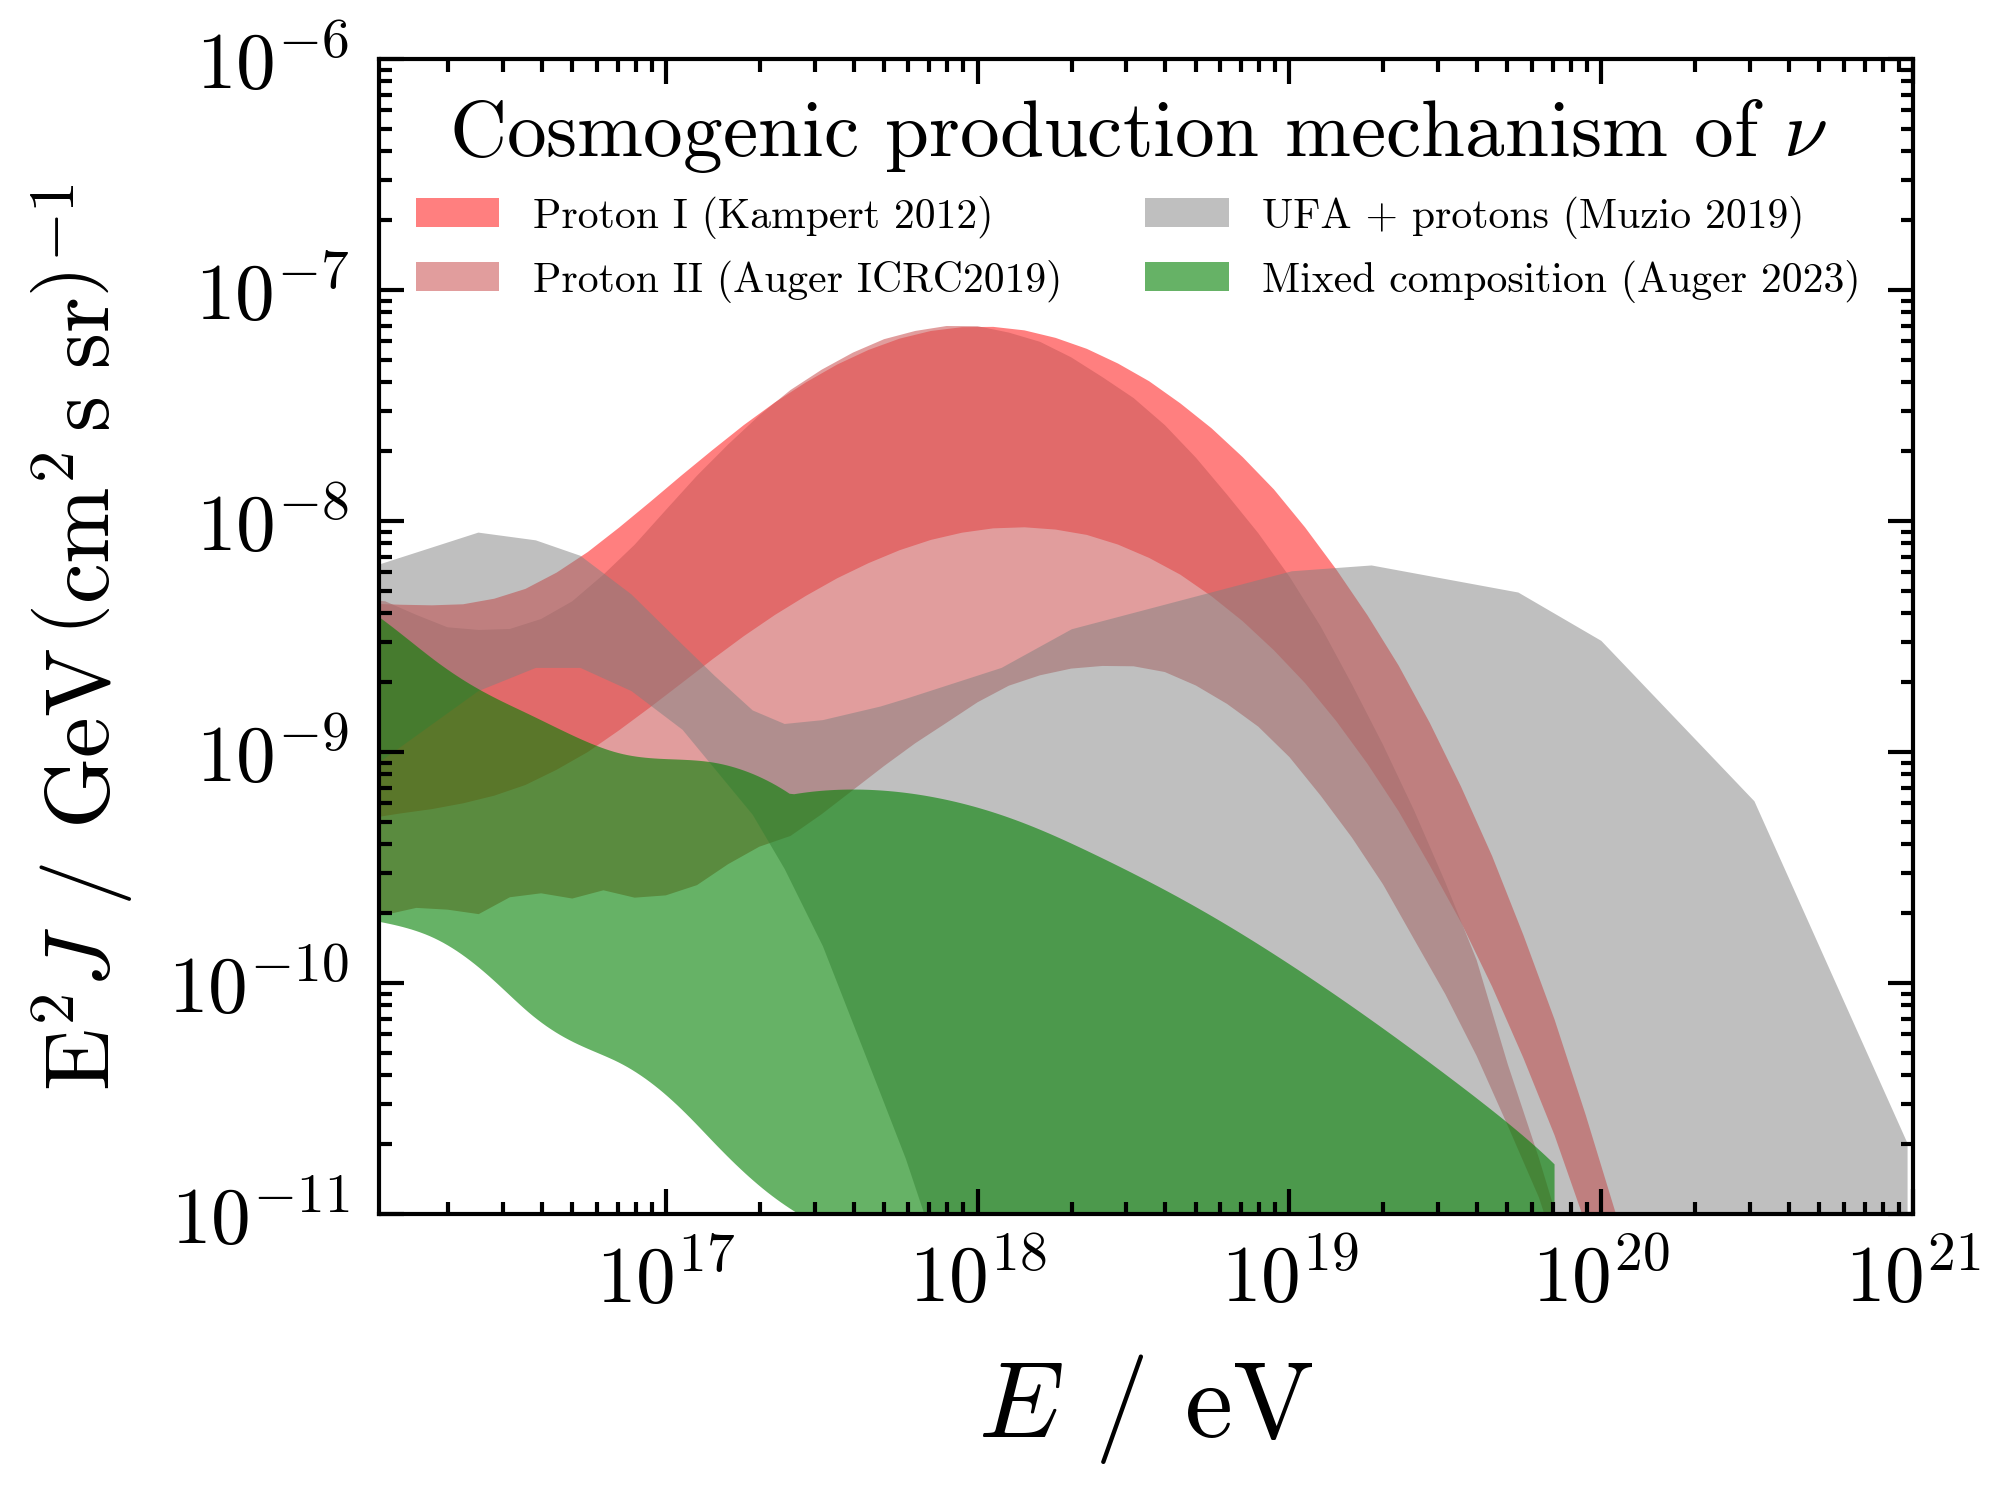

In [27]:
set_plt_style("double")

#####################################################################
#  _____  _       _       
# |  __ \| |     | |      
# | |__) | | ___ | |_ ___ 
# |  ___/| |/ _ \| __/ __|
# | |    | | (_) | |_\__ \
# |_|    |_|\___/ \__|___/
# 
#####################################################################
if __name__ == '__main__':
    fig, ax1 = plt.subplots()

# Fontsize for labels next to lines 
    fs_label=18

# Global variables
    flag_half_decade = 0    # 0=> One decade in log10(E), 1=> Half decade in log10(E) (applies to limits only)
    flag_single_flavor = 0   # 0=> All flavors, 1=> Single flavor (applies to limits and models)
    flag_projected  = 0      # 1=> Plot Projected sensitivities 
    flag_cosmogenic = 1      # 1=> Plot Cosmogenic fluxes 
    flag_astrophys  = 0      # 1=> Plot Astrophysical fluxes 

# Min. and max. values of axes 
    Emin=1.2e16
    Emax=1.e21
    Fmin=1.e-11
    Fmax=3.e-7

    #plot_empty_plot_to_include_white_line_in_legend(" ")
#==========
# Models of neutrino production
#==========
#----------------------------------------------------------------------------------------------
# Some linestyles
#----------------------------------------------------------------------------------------------
# dashed                (0, (5, 5))
# loosely dashed        (0, (5, 10))
# densely dashed        (0, (5, 1))
# dotted                (0, (1, 1))
# loosely_dotted        (0, (1, 10))
# densely dotted        (0, (1, 1))
# long dash with offset (5, (10, 3))
# dashdotted            (0, (3, 5, 1, 5))
# loosely dashdotted    (0, (3, 10, 1, 10))
# densely dashdotted    (0, (3, 1, 1, 1))
# dashdotdotted         (0, (3, 5, 1, 5, 1, 5))
# loosely dashdotdotted (0, (3, 10, 1, 10, 1, 10))
# densely dashdotdotted (0, (3, 1, 1, 1, 1, 1))


#----------------------------------------------------------------------------------------------
# COSMOGENIC 
#----------------------------------------------------------------------------------------------
# PROTON
#----------------------------------------------------------------------------------------------
    if flag_cosmogenic==1: # 0=> Plot Cosmogenic 
       plot_Kampert_p_band_GZK(flag_single_flavor,'red',' ','-',1)
       plot_SimProp_Auger_combined_fit_band_proton(flag_single_flavor,'indianred',' ','-',1)
       plot_Muzio_protons(flag_single_flavor,'gray','None','.-',1)
#----------------------------------------------------------------------------------------------
# MIXED
#----------------------------------------------------------------------------------------------
       plot_SimProp_Auger_combined_fit_band_mixed(flag_single_flavor,'green','None','--',1)
#----------------------------------------------------------------------------------------------

#----------------------------------------------------------------------------------------------
#    plot_empty_plot_to_include_white_line_in_legend(" ")
#----------------------------------------------------------------------------------------------


#----------------------------------------------------------------------------------------------
# ASTROPHYSICAL 
#----------------------------------------------------------------------------------------------
    if flag_astrophys==1: # 0=> Plot astrophysical 
# AGN
#       plot_Murase_AGN(flag_single_flavor,'black','None','--',4, 100)  # psi_CR = 100
       plot_Murase_AGN(flag_single_flavor,'black','None','--',1, 500)  # psi_CR = 500
       plot_Winter_Low_Luminosity_BL_Lacs(flag_single_flavor,'black','None',(0, (1, 1)),1)
       plot_Condorelli_SBG(flag_single_flavor,'black','None','-.',1)
# Pulsars and Magnetars 
#       plot_Fang_Pulsar(flag_single_flavor,'black','None',(0, (2, 1)),4,'SFR')
#       plot_Fang_Pulsar(flag_single_flavor,'black','None','--',4,'uniform')
       plot_Fang_Magnetars_from_BNS_mergers(flag_single_flavor,'black','None',(5, (10, 3)),1)

#----------------------------------------------------------------------------------------------
# Waxman-Bahcall bound
       #plot_WB_bound_2001(flag_single_flavor,'gray','None','--',4)
       plot_WB_bound_2015(flag_single_flavor,'gray','None','--',1)
#----------------------------------------------------------------------------------------------

#==========
# Limits
#==========
#----------------------------------------------------------------------------------------------
# Auger 
#----------------------------------------------------------------------------------------------
    if flag_half_decade == 1:
       scaling=1.   # 1/2 decade in log10(E)
    else:
       scaling=0.5  # 1 decade in log10(E)
    ypos=0.74+flag_half_decade*0.1-flag_single_flavor*0.2
# ------------
# JCAP 2019
# ------------
#    plot_limit_Auger_2019(flag_single_flavor,'red','','--',4)  # 0 => all flavors, 1 => single flavor
#    plt.text(3.0e19, 6.e-9*scaling, "90% CL integral\nlimit Auger (2019)", 
#    horizontalalignment='center', color='darkred', verticalalignment='center', fontsize=fs_label)

#    plot_diff_limit_Auger_2019(scaling,flag_single_flavor,'red','','--',4) # 0 => all flavors, 1 => single flavor
#    plot_diff_limit_Auger_2019_E_minus_1(scaling,flag_single_flavor,4)
#    plt.text(2.0e17, 1.e-7*scaling, "90% CL differential\nlimit Auger (2019)", 
#    horizontalalignment='center', color='darkred', verticalalignment='center', fontsize=fs_label)
# ------------
# Update for UHECR 2022 and ICRC 2023
# ------------
#    plot_limit_Auger_2021(flag_single_flavor,'darkred','','-',4)  # 0 => all flavors, 1 => single flavor
#    plt.text(5.e19, 2.5e-9*scaling, "Auger integral (2022)", 
#    horizontalalignment='center', color='darkred', verticalalignment='center', fontsize=fs_label)

    # plot_diff_limit_Auger_2021(scaling,flag_single_flavor,'darkred','','-',4) # 0 => all flavors, 1 => single
    # plt.text(1.2e17, 9.0e-8*scaling, "Pierre Auger\n(2022)", 
    # horizontalalignment='center', color='darkred', verticalalignment='center', fontsize=fs_label)
#----------------------------------------------------------------------------------------------
# IceCube 
#----------------------------------------------------------------------------------------------
    if flag_half_decade == 1:
       scaling=2  # 1/2 decade in log10(E)
    else:
       scaling=1  # 1 decade in log10(E)
    ypos=0.68+flag_half_decade*0.1-flag_single_flavor*0.2
    # plot_diff_limit_IceCube_2018(scaling,flag_single_flavor,'darkgreen','','-',4) # 0 => all flavors, 1 => single 
#    plt.text(0.1, ypos,"90% CL limit\nIceCube (2018)", horizontalalignment='center', color='g', 
#             verticalalignment='center', transform=plt.gca().transAxes, fontsize=fs_label)
    #plt.text(4.5e16,4.e-8/scaling,"90% CL differential \nlimit IceCube (2018)", 
    # plt.text(5.e18,1.3e-7/scaling,"IceCube (2018)", 
    # horizontalalignment='center', color='g', verticalalignment='center', fontsize=fs_label)
#
#    plot_diff_limit_IceCube_2023(scaling,flag_single_flavor,'darkgreen','','-',4) # 0 => all flavors, 1 => single 
#    plt.text(2.5e20,2.5e-7/scaling,"IceCube (2023)", 
#    horizontalalignment='center', color='g', verticalalignment='center', fontsize=fs_label)
#----------------------------------------------------------------------------------------------
# ANITA 
#----------------------------------------------------------------------------------------------
    if flag_half_decade == 1:
       scaling=1  # 1/2 decade in log10(E)
    else:
       scaling=0.5 # 1 decade in log10(E)
#----------------------------------------------------------------------------------------------
    ypos=0.83+flag_half_decade*0.1-flag_single_flavor*0.2
    fx=-(flag_single_flavor-1)*0.05
    # plot_diff_limit_ANITA_I_II_III_IV_2019(scaling,flag_single_flavor,'m','','-',4) # 0 => all flavors, 1=> single
#    plt.text(0.8, ypos,"90% CL limit\nANITA I+II+III+IV (2019)", horizontalalignment='center', color='m', 
#    plt.text(0.86+fx, ypos,"90% CL limit\nANITA (2019)", horizontalalignment='center', color='m', 
#             verticalalignment='center', transform=plt.gca().transAxes, fontsize=fs_label)
    # plt.text(2.5e20, 8.e-8*scaling,"ANITA I-IV (2019)", 
    # horizontalalignment='center', color='m', verticalalignment='center', fontsize=fs_label)
#----------------------------------------------------------------------------------------------
# -----> Axis on the left 
# Labels
    ax1.set_xlabel("$E$ / eV")
    ax1.set_ylabel(r"E$^2J$ / $\mathrm{GeV}\,\left( \mathrm{cm}^2\,\mathrm{s}\,\,\mathrm{sr} \right)^{-1}$", fontsize=11)
# Axes: ticks, scale, lims,...
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    # ax1.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=15))
    ax1.set_xlim(Emin, Emax)
    # ax1.set_ylim(1e6, 1.2e12)
    ax1.set_ylim(Fmin, 1.1 * Fmax)
    # plt.tick_params(axis='both', which='major', length=10, width=1.5, top=True, right=True, labelsize=fs)
    # plt.tick_params(axis='both', which='minor', length=6, width=1., top=True, right=True, labelsize=fs)
#    ax1.grid(linestyle='-.', linewidth=1)

# Legends - WARNING: Place the following line here before the new axis is used
    handles, labels = plt.gca().get_legend_handles_labels()

# -----> Axis on the right 
    # ax2 = ax1.twinx()
    # ax2.set_ylabel("E$^2$ dN/dE (EeV km$^{-2}$ yr$^{-1}$ sr$^{-1}$)",fontsize=18)
    # factor=1.e-9*365.25*24.*3600.*1.e10  # Convert from GeV cm-2 s-1 sr-1 to EeV km-2 yr-1 sr-1
    # y1, y2 = ax1.get_ylim() 
    # ax2.set_ylim(y1*factor,y2*factor)
    # ax2.set_yscale('log')
    # ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
    # plt.tick_params(axis='both', which='major', length=10, width=1.5, top=True, right=True, labelsize=fs)
    # plt.tick_params(axis='both', which='minor', length=6, width=1., top=True, right=True, labelsize=fs)


# More plot labels
    if flag_single_flavor==1:
        text_flavor='Single flavor'
    else:
        text_flavor='All flavors'

    if flag_half_decade==1:
        text_decade='0.5 decade $log_{10}$E'
    else:
        text_decade='1 decade $log_{10}$E'


    # plt.text(0.89, 0.08, text_flavor, horizontalalignment='center', verticalalignment='center', 
    #          transform=plt.gca().transAxes, fontsize=fs_label)

    # plt.text(0.89, 0.03, text_decade, horizontalalignment='center', verticalalignment='center', 
    #          transform=plt.gca().transAxes, fontsize=fs_label)

#    plt.text(0.7, 0.35, 'PRELIMINARY', fontsize=28, color='red', alpha=1.0,
#        ha='left', va='center', transform=plt.gca().transAxes)


    xlegend=0.5
    ylegend=1.2

# Unsorted legends
#    plt.legend(handles,labels, loc='upper center', bbox_to_anchor=(xlegend,ylegend), ncol=2, 
#      fancybox=True, handlelength=4.5, framealpha=1.0, shadow=False, numpoints=1, fontsize=fs_label)

# Plot sorted legends
#    order=[0,6,7,1,2,3,5,4]  # order in my laptop - don't know why
    if flag_cosmogenic==1 and flag_astrophys==1:  # Plot cosmogenic and astrophysical models
       order=[0,1,2,3,4,5,6,7]   # in my desktop
       ncolumns=2
       fs_label=14
    elif flag_cosmogenic==1 and flag_astrophys==0:  # Plot cosmogenic only
       order=[0,1,3,2]   
       ncolumns=1
       fs_label=18
    elif flag_cosmogenic==0 and flag_astrophys==1:  # Plot astrophysical only
       order=[0,1,2,3]   
       ncolumns=1
       fs_label=18

    plt.legend(title=r'Cosmogenic production mechanism of $\nu$', loc='upper left', fontsize=5, ncol=2)
    plt.ylim(1e-11, 1e-6)

    # fig.tight_layout()

    # plt.savefig("limits_and_models_wiki.pdf")

#    plt.show()

